In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [3]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

print(train.shape)
print(test.shape)

(2000, 8)
(500, 7)


In [4]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [5]:
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [7]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [9]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [10]:
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

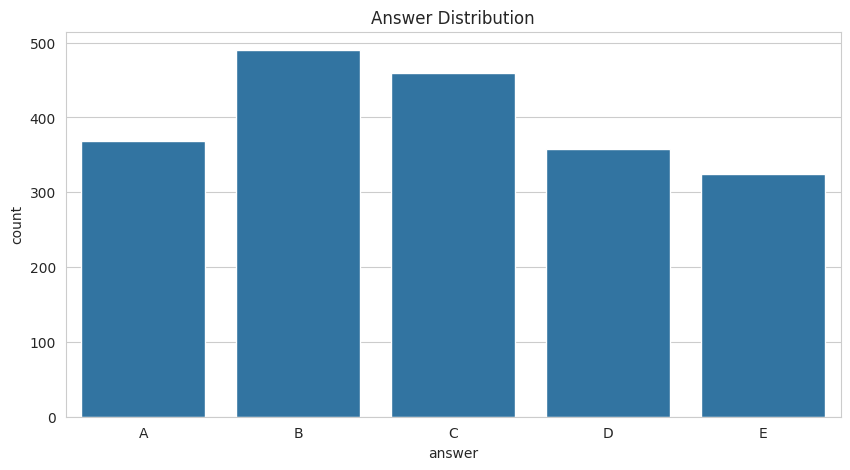

In [11]:
sns.countplot(data=train, x="answer", order=sorted(train.answer.unique()))

plt.title("Answer Distribution")
plt.show()

In [12]:
(train.answer.value_counts(normalize=True)*100).round(2)

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

In [13]:
train["prompt_chars"] = train["prompt"].str.len()

train["prompt_chars"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_chars, dtype: float64

In [14]:
train["prompt_words"] = train["prompt"].str.split().apply(len)

train["prompt_words"].describe()

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_words, dtype: float64

In [15]:
options = ['A','B','C','D','E']

for col in options:
    train[f"{col}_chars"] = train[col].astype(str).str.len()
    train[f"{col}_words"] = train[col].astype(str).str.split().apply(len)

In [16]:
train[[f"{c}_words" for c in options]].describe()

,A_words,B_words,C_words,D_words,E_words
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,26.146000,26.516000,26.54950,25.999500,26.187000
std,17.249651,18.653893,17.20987,17.098909,17.852658
min,1.000000,1.000000,1.00000,1.000000,1.000000
25%,13.000000,12.000000,14.75000,15.000000,13.000000
50%,22.000000,23.000000,24.00000,22.000000,23.000000
75%,37.000000,36.000000,36.00000,36.000000,36.000000
max,81.000000,118.000000,82.00000,78.000000,105.000000


In [17]:
train.nlargest(10,"prompt_words")[["prompt","answer"]]

,prompt,answer
1484,Select the most accurate option: What is one o...,C
1980,Identify the correct statement: What is one of...,C
574,Choose the correct answer: What is one of the ...,C
1164,Determine the correct option: What is one of t...,C
1611,Determine the correct option: What is one of t...,C
1549,Choose the correct answer: What is one of the ...,C
1745,What is one of the examples of the models prop...,C
370,Which of the following is correct? What is the...,B
1687,Which of the following is correct? What is the...,B
1099,Pick the best possible answer: What is the rev...,B


In [18]:
train.nsmallest(10,"prompt_words")[["prompt","answer"]]

,prompt,answer
479,What is emissivity?,C
1398,What is resistivity?,C
1510,What is organography?,B
34,What is a pycnometer?,D
319,What is a light-year?,B
466,What is spatial dispersion?,D
553,What is indirect photophoresis?,D
592,What is Minkowski space?,B
760,What is radiometric dating?,B
1283,What is a phageome?,C
